In [19]:
import nltk
import json
import pandas as pd
import numpy as np
import seaborn as sns

from nltk.corpus import stopwords
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from IPython.display import display
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


from storage.database import Database

In [3]:
BASE_URL = "https://dadosabertos.camara.leg.br/api/v2/"
DATABASE_PATH = "../data.db"


try:
    stopwords.words('portuguese')
except LookupError:
    nltk.download('stopwords')
nltk.download('rslp')

[nltk_data] Downloading package rslp to
[nltk_data]     C:\Users\micael.conti\AppData\Roaming\nltk_data...
[nltk_data]   Package rslp is already up-to-date!


True

In [4]:
database = Database(DATABASE_PATH)

In [5]:
def mostrar_tabela(x,vec,title):
    df_bow = pd.DataFrame(x.toarray(), columns=vec.get_feature_names_out())
    print(title)
    display(df_bow)

In [7]:
def processar_dados_bow(campo):
    discursos = database.get_discursos(10)
    
    corpus = [json.loads(d[campo]) for d in discursos]
    
    bow_vec = CountVectorizer(
        tokenizer=lambda x: x,
        preprocessor=None,
        lowercase=False
    )
    
    X_bow = bow_vec.fit_transform(corpus)
    
    return X_bow, bow_vec,corpus

In [8]:
X_bow,bow_vec,bow_corpus = processar_dados_bow("sumario_stemizado")
mostrar_tabela(X_bow,bow_vec,"Matriz Documento-Termo (BoW):")

Matriz Documento-Termo (BoW):


c:\GIT\scrap\Trabalho\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


,abr,acess,aere,aeroport,afet,agenc,agradec,aguinald,alhei,aliquot,...,urgenc,uso,val,valorizaca,vet,viag,vid,viv,voo,votaca
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,...,0,1,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,1,0,...,0,0,1,0,0,0,1,1,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,1
4,0,0,3,1,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,1,0
5,1,0,0,0,0,0,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
7,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,0,0,...,1,0,0,0,0,0,0,0,0,1
9,0,0,0,0,1,1,1,0,0,0,...,0,0,0,0,1,1,0,0,0,0


In [9]:
def processar_dados_td_idf(campo,size):
    discursos = database.get_discursos(size)
    
    corpus = [
        json.loads(d[campo])
        for d in discursos
        if campo in d and d[campo]
    ]    
    
    tfidf_vec = TfidfVectorizer(
        lowercase=False,
        preprocessor=None, # Usa a lista de stopwords corrigida
        tokenizer=lambda x: x
    )
    
    X_tfidf = tfidf_vec.fit_transform(corpus)
    
    return X_tfidf, tfidf_vec, corpus

In [16]:
QUANTITY = 10000

x1,vec1,corpus1 = processar_dados_td_idf("transcricao_tokens", QUANTITY)
x2,vec2,corpus2 = processar_dados_td_idf("transcricao_stemizado", QUANTITY)
x3,vec3,corpus3 = processar_dados_td_idf("transcricao_lemizado", QUANTITY)

mostrar_tabela(x1,vec1,"Matriz Documento-Termo (TF-IDF)")

c:\GIT\scrap\Trabalho\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:526: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


Matriz Documento-Termo (TF-IDF)


,aa,aaa,aagd,aahmsnpvoqltgxmwqhxayhuogwymsawumwkealpawgyovwmehehxe,aaktzkyq,aapdp,aarao,abacateiro,abacaxi,abacc,...,zuliani,zumbi,zumbilandia,zunzunzum,zur,zurab,zwgxf,zxkj,zyon,zyrhfqo
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9833,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9834,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9835,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9836,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [15]:
def search_and_rank(query, vectorizer, X_corpus, corpus, method_name):
    """
    Vetoriza uma query, calcula a similaridade com o corpus e exibe os resultados.
    """
    q_vec = vectorizer.transform([query])
    sim_scores = cosine_similarity(q_vec, X_corpus).ravel()
    rank = np.argsort(sim_scores)[::-1]

    print(f"Top-3 Similares para a Query (usando {method_name}):")
    for i in rank[:3]:
        if sim_scores[i] > 0.01: # Apenas mostra se houver alguma similaridade
            print(f"  Doc{i+1} (score={sim_scores[i]:.3f}): {corpus[i]}")
    print("-" * 40)

In [17]:
query = "educacao publica investimento escolas professores"

print(f">> Executando busca para a query: '{query}'\n")

search_and_rank(query, bow_vec, X_bow, bow_corpus, "BoW")
search_and_rank(query, vec1, x1, corpus1, "TF-IDF")

>> Executando busca para a query: 'educacao publica investimento escolas professores'

Top-3 Similares para a Query (usando BoW):
  Doc4 (score=0.354): ['deput', 'encaminh', 'votaca', 'recurs', 'apreciaca', 'termin', 'incis', 'i', 'caput', 'art', 'd', 'lei', 'n', 'cont', 'art', 'substitu', 'sen', 'feder', 'apresent', 'projet', 'lei', 'n', 'alt', 'lei', 'n', 'dezembr', 'lei', 'diretriz', 'bas', 'educaca', 'nacion', 'defin', 'diretriz', 'ensin', 'medi']
  Doc7 (score=0.223): ['deput', 'discut', 'projet', 'lei', 'n', 'alt', 'lei', 'n', 'mai', 'estabelec', 'aliquot', 'reduz', 'ambit', 'program', 'emerg', 'retom', 'set', 'event', 'pers']
  Doc9 (score=0.143): ['deput', 'encaminh', 'votaca', 'requer', 'urgenc', 'apreciaca', 'projet', 'lei', 'n', 'dispo', 'criaca', 'dia', 'rei', 'pel']
----------------------------------------
Top-3 Similares para a Query (usando TF-IDF):
  Doc7626 (score=0.320): ['sr', 'diego', 'andrade', 'psd', 'mg', 'ordem', 'revisao', 'orador', 'sr', 'presidente', 'autor',

Calculando a matriz de similaridade de cossenos...


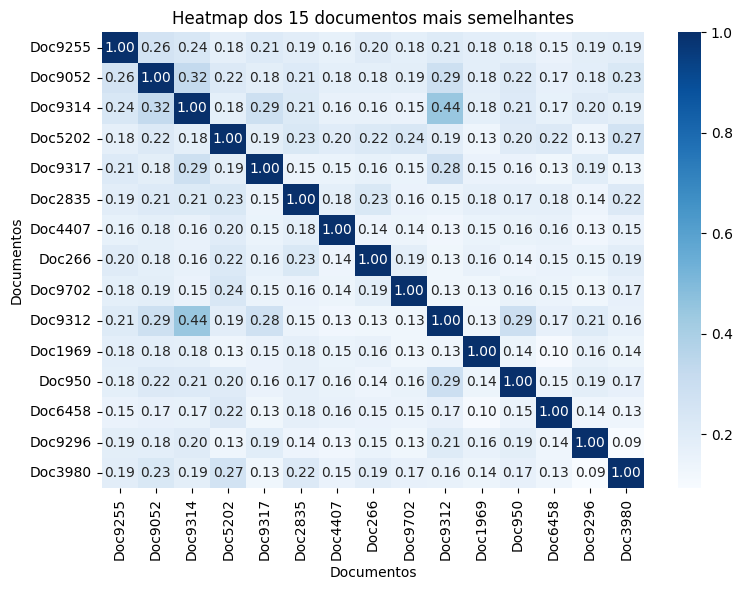

In [18]:
print("Calculando a matriz de similaridade de cossenos...")

sim_matrix = cosine_similarity(x1, x1)

sim_no_diag = sim_matrix.copy()
np.fill_diagonal(sim_no_diag, 0)

mean_sim = sim_no_diag.mean(axis=1)
top_n = 15
top_idxs = np.argsort(mean_sim)[::-1][:top_n]

sub_sim = sim_matrix[np.ix_(top_idxs, top_idxs)]
doc_labels = [f"Doc{i+1}" for i in top_idxs]

df_similarity = pd.DataFrame(sub_sim, index=doc_labels, columns=doc_labels)

plt.figure(figsize=(8, 6))
sns.heatmap(df_similarity, annot=True, cmap="Blues", fmt=".2f")
plt.title(f"Heatmap dos {top_n} documentos mais semelhantes")
plt.xlabel("Documentos")
plt.ylabel("Documentos")
plt.tight_layout()
plt.show()

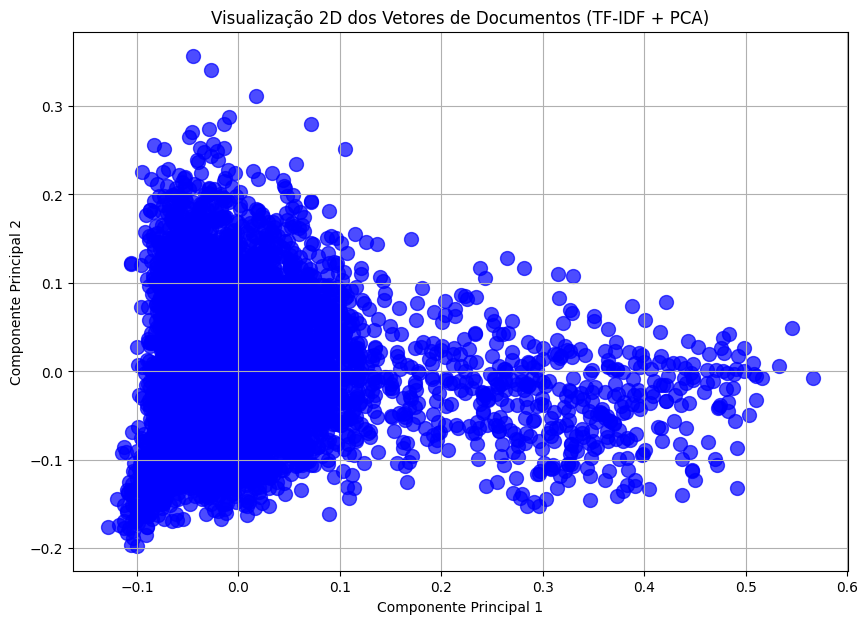

In [32]:
# b) Visualização dos Documentos em 2D com PCA
pca = PCA(n_components=2)
# Usamos .toarray() para converter a matriz esparsa para uma matriz densa
X_tfidf_pca = pca.fit_transform(x1.toarray())

plt.figure(figsize=(10, 7))
plt.scatter(X_tfidf_pca[:, 0], X_tfidf_pca[:, 1], c='blue', alpha=0.7, s=100)
plt.title("Visualização 2D dos Vetores de Documentos (TF-IDF + PCA)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.grid(True)

# Adiciona anotações para cada ponto
plt.show()

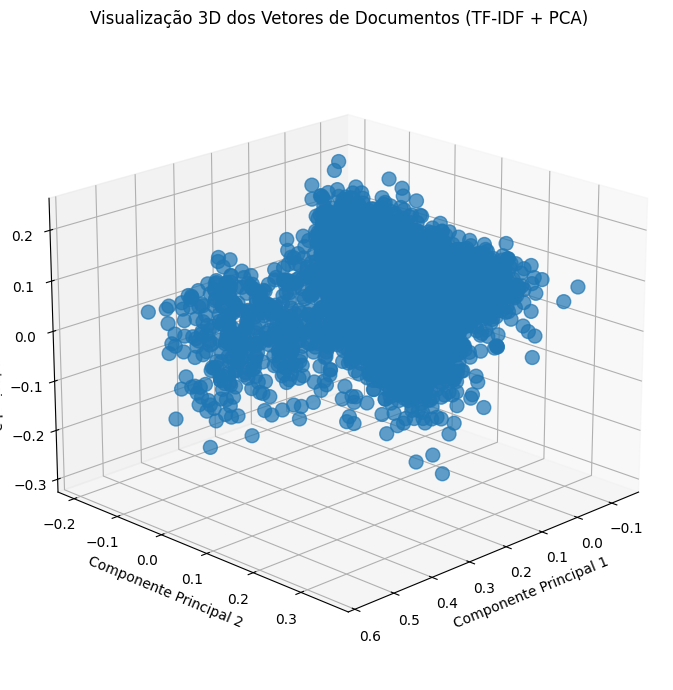

In [ ]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from sklearn.decomposition import PCA

# 🔹 PCA com 3 componentes
pca = PCA(n_components=3)
X_tfidf_pca = pca.fit_transform(x1.toarray())

# 🔹 Criar figura 3D
fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection='3d')

# 🔹 Scatter plot
ax.scatter(
    X_tfidf_pca[:, 0],
    X_tfidf_pca[:, 1],
    X_tfidf_pca[:, 2],
    alpha=0.7,
    s=100
)

# 🔹 Títulos e labels
ax.set_title("Visualização 3D dos Vetores de Documentos (TF-IDF + PCA)")
ax.set_xlabel("Componente Principal 1")
ax.set_ylabel("Componente Principal 2")
ax.set_zlabel("Componente Principal 3")

# 🔹 Grid (opcional)
ax.grid(True)

# 🔹 Ajuste de ângulo inicial (opcional)
ax.view_init(elev=20, azim=45)

# 🔹 Exibir gráfico
plt.tight_layout()
plt.show()